# CNN-1D với raw impedance spectra trên common frequency grid

Notebook này **thay thế SVM** bằng một **1D Convolutional Neural Network (CNN-1D)**.

Toàn bộ pipeline xử lý dữ liệu được giữ nguyên — chỉ phần model thay đổi.

## Input tensor shape

```text
(n_samples, n_common_frequencies, n_channels)
= (n_samples, 30, 6)
```

Với CNN-1D, ta không cần flatten — mỗi frequency point là một **timestep**, mỗi channel là một **feature tại timestep đó**. Đây chính là lợi thế so với SVM.

## Các channels (giống SVM notebook)

| Index | Channel |
|-------|---------|
| 0 | `real(Z)` |
| 1 | `imag(Z)` |
| 2 | `magnitude = |Z|` |
| 3 | `phase = angle(Z)` |
| 4 | `log10(frequency)` |
| 5 | `dphase / dlog10(frequency)` |

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

RANDOM_STATE = 42
N_COMMON_FREQ = 30

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("dataset") if Path("dataset/train_data.csv").exists() else Path(".")
TRAIN_FILE = DATA_DIR / "train_data.csv"
TEST_FILE  = DATA_DIR / "test_data.csv"

print("Train file:", TRAIN_FILE.resolve())
print("Test file :", TEST_FILE.resolve())

TensorFlow version: 2.13.1
GPU available: []
Train file: D:\TUChemnitz\2.Sem\1. Project Lab Embedded Systems\mini-belt-characterization\software_host\MiuLe\dataset\train_data.csv
Test file : D:\TUChemnitz\2.Sem\1. Project Lab Embedded Systems\mini-belt-characterization\software_host\MiuLe\dataset\test_data.csv


## 1. Parser functions

*(Giữ nguyên từ SVM notebook)*

In [2]:
def parse_float_array(s: str) -> np.ndarray:
    """Parse a string representation of a float array, e.g. '[1.0, 2.0, 3.0]'."""
    s = str(s).strip()
    if s.startswith("["):
        s = s[1:]
    if s.endswith("]"):
        s = s[:-1]
    arr = np.fromstring(s.replace(",", " "), sep=" ")
    return arr.astype(float)


def parse_complex_array(s: str) -> np.ndarray:
    """
    Parse a string representation of a complex array.
    Handles values like: '2.6537056 -6.91795864e-04j'
    """
    s = str(s).strip()
    if s.startswith("["):
        s = s[1:]
    if s.endswith("]"):
        s = s[:-1]
    tokens = [tok.strip() for tok in s.split(",") if tok.strip()]
    values = []
    for tok in tokens:
        tok_clean = tok.replace(" ", "")
        values.append(complex(tok_clean))
    return np.asarray(values, dtype=np.complex128)

## 2. Common logarithmic frequency grid

*(Giữ nguyên từ SVM notebook)*

In [3]:
def get_frequency_ranges(df: pd.DataFrame):
    min_freqs, max_freqs = [], []
    for freq_str in df["freq"]:
        freq = parse_float_array(freq_str)
        if len(freq) == 0:
            raise ValueError("Empty frequency array found.")
        min_freqs.append(np.min(freq))
        max_freqs.append(np.max(freq))
    return np.asarray(min_freqs), np.asarray(max_freqs)


def choose_common_frequency_grid(train_df: pd.DataFrame, n_points: int = 30) -> np.ndarray:
    min_freqs, max_freqs = get_frequency_ranges(train_df)
    f_start = np.max(min_freqs)
    f_stop  = np.min(max_freqs)
    if f_start >= f_stop:
        raise ValueError(f"No common frequency overlap. f_start={f_start}, f_stop={f_stop}")
    common_freq = np.logspace(np.log10(f_start), np.log10(f_stop), n_points)
    return common_freq


train_df_preview = pd.read_csv(TRAIN_FILE)
common_freq = choose_common_frequency_grid(train_df_preview, n_points=N_COMMON_FREQ)

print(f"Common frequency grid: {len(common_freq)} points")
print(f"Start: {common_freq[0]:.6g} Hz")
print(f"Stop : {common_freq[-1]:.6g} Hz")

Common frequency grid: 30 points
Start: 10 Hz
Stop : 100000 Hz


## 3. Interpolate spectrum to common grid

*(Giữ nguyên từ SVM notebook)*

In [4]:
def spectrum_to_raw_features(
    freq: np.ndarray,
    z: np.ndarray,
    common_freq: np.ndarray,
) -> np.ndarray:
    """
    Output shape: (n_common_frequencies, 6)

    Channels:
        0: real(Z)
        1: imag(Z)
        2: magnitude |Z|
        3: phase angle(Z), unwrapped
        4: log10(frequency)
        5: dphase / dlog10(frequency)
    """
    freq = np.asarray(freq, dtype=float)
    z = np.asarray(z, dtype=np.complex128)

    order = np.argsort(freq)
    freq = freq[order]
    z = z[order]

    freq_unique, unique_idx = np.unique(freq, return_index=True)
    freq = freq_unique
    z = z[unique_idx]

    log_freq   = np.log10(freq)
    log_common = np.log10(common_freq)

    real_interp = np.interp(log_common, log_freq, z.real)
    imag_interp = np.interp(log_common, log_freq, z.imag)

    z_interp  = real_interp + 1j * imag_interp
    magnitude = np.abs(z_interp)
    phase     = np.unwrap(np.angle(z_interp))

    dphase_dlogf = np.gradient(phase, log_common)
    logf_channel = log_common.copy()

    features = np.stack(
        [real_interp, imag_interp, magnitude, phase, logf_channel, dphase_dlogf],
        axis=1,
    )
    return features  # shape: (N_COMMON_FREQ, 6)

## 4. Load dataset

Output shape: `(n_samples, 30, 6)` — **không flatten**, đây là format native cho CNN-1D.

In [5]:
def load_raw_spectral_dataset(filepath: Path, common_freq: np.ndarray):
    df = pd.read_csv(filepath)
    X_list, y_list = [], []
    for _, row in df.iterrows():
        freq = parse_float_array(row["freq"])
        z    = parse_complex_array(row["Z"])
        features = spectrum_to_raw_features(freq, z, common_freq)
        X_list.append(features)
        y_list.append(row["Circuit"])
    X_raw = np.stack(X_list, axis=0)  # (n_samples, 30, 6)
    y = np.asarray(y_list)
    return X_raw, y


print("Loading training data ...")
X_train_full_raw, y_train_full = load_raw_spectral_dataset(TRAIN_FILE, common_freq)

print("Loading final test data ...")
X_test_raw, y_test = load_raw_spectral_dataset(TEST_FILE, common_freq)

print("X_train_full_raw:", X_train_full_raw.shape)  # (N, 30, 6)
print("X_test_raw      :", X_test_raw.shape)
print("y_train_full    :", y_train_full.shape)

Loading training data ...
Loading final test data ...
X_train_full_raw: (7462, 30, 6)
X_test_raw      : (1865, 30, 6)
y_train_full    : (7462,)


## 5. Encode labels và train/val split

In [6]:
label_encoder = LabelEncoder()
y_train_full_enc = label_encoder.fit_transform(y_train_full)
y_test_enc       = label_encoder.transform(y_test)

n_classes = len(label_encoder.classes_)
print(f"Classes ({n_classes}): {list(label_encoder.classes_)}")

# One-hot encode cho keras categorical crossentropy
y_train_full_oh = keras.utils.to_categorical(y_train_full_enc, n_classes)
y_test_oh       = keras.utils.to_categorical(y_test_enc, n_classes)

(
    X_train_raw, X_val_raw,
    y_train_oh,  y_val_oh,
    y_train_enc, y_val_enc,
) = train_test_split(
    X_train_full_raw,
    y_train_full_oh,
    y_train_full_enc,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full_enc,
)

print("Train      :", X_train_raw.shape)
print("Validation :", X_val_raw.shape)
print("Test       :", X_test_raw.shape)

Classes (9): ['L-R-RCPE', 'L-R-RCPE-RCPE', 'L-R-RCPE-RCPE-RCPE', 'RC-G-G', 'RC-RC-RCPE-RCPE', 'RCPE-RCPE', 'RCPE-RCPE-RCPE', 'RCPE-RCPE-RCPE-RCPE', 'Rs_Ws']
Train      : (5969, 30, 6)
Validation : (1493, 30, 6)
Test       : (1865, 30, 6)


## 6. Normalize features

Normalize **per channel** (axis 0 và 1) để mỗi channel có mean=0, std=1.

Scaler được fit **chỉ trên training data**, sau đó apply cho val và test.

In [7]:
# Reshape sang 2D để dùng StandardScaler, sau đó reshape lại
n_train, n_freq, n_ch = X_train_raw.shape

X_train_2d = X_train_raw.reshape(-1, n_ch)  # (n_train * n_freq, 6)

scaler = StandardScaler()
X_train_2d_scaled = scaler.fit_transform(X_train_2d)

X_train = X_train_2d_scaled.reshape(n_train, n_freq, n_ch)
X_val   = scaler.transform(X_val_raw.reshape(-1, n_ch)).reshape(X_val_raw.shape)
X_test  = scaler.transform(X_test_raw.reshape(-1, n_ch)).reshape(X_test_raw.shape)

print("X_train shape after scaling:", X_train.shape)  # (N, 30, 6)
print("Mean of train channels (should be ~0):", X_train.mean(axis=(0,1)).round(4))
print("Std  of train channels (should be ~1):", X_train.std(axis=(0,1)).round(4))

X_train shape after scaling: (5969, 30, 6)
Mean of train channels (should be ~0): [-0.  0. -0.  0. -0. -0.]
Std  of train channels (should be ~1): [1. 1. 1. 1. 1. 1.]


## 7. Xây dựng CNN-1D model

### Kiến trúc

```
Input: (30, 6)   ← 30 frequency points, 6 channels
  │
  ├─ Conv1D(64, kernel=3, padding='same') + BatchNorm + ReLU
  ├─ Conv1D(64, kernel=3, padding='same') + BatchNorm + ReLU
  ├─ MaxPool1D(2)
  │
  ├─ Conv1D(128, kernel=3, padding='same') + BatchNorm + ReLU
  ├─ Conv1D(128, kernel=3, padding='same') + BatchNorm + ReLU
  ├─ GlobalAveragePooling1D()
  │
  ├─ Dense(128) + ReLU + Dropout(0.4)
  └─ Dense(n_classes, softmax)
```

**Tại sao GlobalAveragePooling thay vì Flatten?**  
Dataset nhỏ → dùng GAP giảm số parameters, tránh overfitting tốt hơn.

**Tại sao `padding='same'`?**  
Với N_COMMON_FREQ=30 (nhỏ), `same` giữ nguyên chiều dài, tránh mất thông tin biên.

In [8]:
def build_cnn1d(n_freq: int, n_channels: int, n_classes: int, l2: float = 1e-4) -> keras.Model:
    """
    1D CNN for impedance spectrum classification.

    Input shape : (n_freq, n_channels)  e.g. (30, 6)
    Output shape: (n_classes,)          softmax probabilities
    """
    reg = regularizers.l2(l2)

    inp = keras.Input(shape=(n_freq, n_channels), name="spectrum_input")

    # ── Block 1 ──────────────────────────────────────────────────────────────
    x = layers.Conv1D(64, kernel_size=3, padding="same", kernel_regularizer=reg, name="conv1_1")(inp)
    x = layers.BatchNormalization(name="bn1_1")(x)
    x = layers.Activation("relu", name="act1_1")(x)

    x = layers.Conv1D(64, kernel_size=3, padding="same", kernel_regularizer=reg, name="conv1_2")(x)
    x = layers.BatchNormalization(name="bn1_2")(x)
    x = layers.Activation("relu", name="act1_2")(x)

    x = layers.MaxPooling1D(pool_size=2, name="pool1")(x)  # (15, 64)

    # ── Block 2 ──────────────────────────────────────────────────────────────
    x = layers.Conv1D(128, kernel_size=3, padding="same", kernel_regularizer=reg, name="conv2_1")(x)
    x = layers.BatchNormalization(name="bn2_1")(x)
    x = layers.Activation("relu", name="act2_1")(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same", kernel_regularizer=reg, name="conv2_2")(x)
    x = layers.BatchNormalization(name="bn2_2")(x)
    x = layers.Activation("relu", name="act2_2")(x)

    # ── Global pooling ────────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling1D(name="gap")(x)  # (128,)

    # ── Classifier head ──────────────────────────────────────────────────────
    x = layers.Dense(128, activation="relu", kernel_regularizer=reg, name="fc1")(x)
    x = layers.Dropout(0.4, name="dropout")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inp, outputs=out, name="CNN1D_ImpedanceClassifier")
    return model


model = build_cnn1d(
    n_freq=N_COMMON_FREQ,
    n_channels=X_train.shape[-1],  # 6
    n_classes=n_classes,
)

model.summary()

Model: "CNN1D_ImpedanceClassifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 spectrum_input (InputLayer  [(None, 30, 6)]           0         
 )                                                               
                                                                 
 conv1_1 (Conv1D)            (None, 30, 64)            1216      
                                                                 
 bn1_1 (BatchNormalization)  (None, 30, 64)            256       
                                                                 
 act1_1 (Activation)         (None, 30, 64)            0         
                                                                 
 conv1_2 (Conv1D)            (None, 30, 64)            12352     
                                                                 
 bn1_2 (BatchNormalization)  (None, 30, 64)            256       
                                         

## 8. Compile và training

In [9]:
# ── Compile ──────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# ── Callbacks ────────────────────────────────────────────────────────────────
# IMPORTANT:
# In some TensorFlow/Keras 3 combinations, ModelCheckpoint(filepath="*.keras")
# can fail with:
#   ValueError: The following argument(s) are not supported with the native Keras format: ['options']
#
# We therefore do NOT checkpoint the full .keras model during training.
# EarlyStopping with restore_best_weights=True is enough to restore the best
# validation-loss weights after training.
cb_early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1,
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1,
)

training_callbacks = [cb_early_stop, cb_reduce_lr]

# Optional safe checkpoint:
# If you really want a checkpoint file, save weights only in HDF5 format.
# This avoids the Keras 3 native-format "options" error.
USE_WEIGHTS_CHECKPOINT = False

if USE_WEIGHTS_CHECKPOINT:
    cb_checkpoint = callbacks.ModelCheckpoint(
        filepath="best_cnn1d.weights.h5",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    )
    training_callbacks.append(cb_checkpoint)

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE = 32
EPOCHS     = 200

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=training_callbacks,
    verbose=1,
)

print(f"\nBest val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Stopped at epoch : {len(history.history['loss'])}")

# Optional: save the final in-memory model after training.
# Because EarlyStopping has restore_best_weights=True, this saved model already
# contains the best validation-loss weights.
SAVE_FINAL_KERAS_MODEL = False

if SAVE_FINAL_KERAS_MODEL:
    model.save("cnn1d_impedance_best_restored.keras")
    print("Saved model to cnn1d_impedance_best_restored.keras")


Epoch 1/200
187/187 [==============================] - 7s 18ms/step - loss: 1.9944 - accuracy: 0.2783 - val_loss: 2.0266 - val_accuracy: 0.2552 - lr: 0.0010
Epoch 2/200
187/187 [==============================] - 3s 14ms/step - loss: 1.7956 - accuracy: 0.3444 - val_loss: 1.7546 - val_accuracy: 0.3423 - lr: 0.0010
Epoch 3/200
187/187 [==============================] - 3s 15ms/step - loss: 1.7218 - accuracy: 0.3674 - val_loss: 1.7615 - val_accuracy: 0.3456 - lr: 0.0010
Epoch 4/200
187/187 [==============================] - 3s 15ms/step - loss: 1.6559 - accuracy: 0.3850 - val_loss: 1.7803 - val_accuracy: 0.3530 - lr: 0.0010
Epoch 5/200
187/187 [==============================] - 3s 14ms/step - loss: 1.6311 - accuracy: 0.3917 - val_loss: 1.8939 - val_accuracy: 0.2539 - lr: 0.0010
Epoch 6/200
187/187 [==============================] - 3s 15ms/step - loss: 1.5954 - accuracy: 0.4014 - val_loss: 1.9647 - val_accuracy: 0.2753 - lr: 0.0010
Epoch 7/200
187/187 [==============================] - 3s 

## 9. Plot training curves

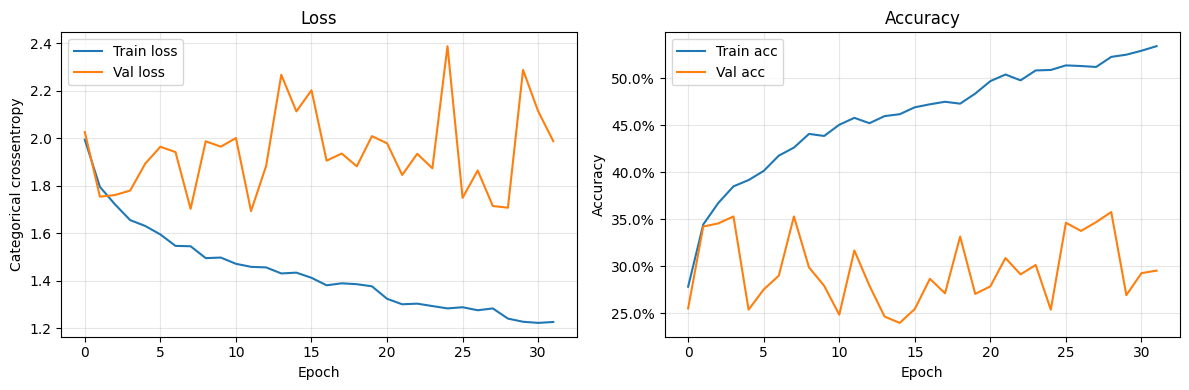

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Categorical crossentropy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history["accuracy"],     label="Train acc")
axes[1].plot(history.history["val_accuracy"], label="Val acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 10. Evaluate model

*(Cùng format với SVM notebook để dễ so sánh)*

In [11]:
def evaluate_model(name: str, X: np.ndarray, y_true_enc: np.ndarray, y_oh: np.ndarray):
    y_pred_prob = model.predict(X, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)

    loss, acc = model.evaluate(X, y_oh, verbose=0)

    print(f"\n── {name} Results ──────────────────────────────")
    print(f"Loss       : {loss:.4f}")
    print(f"Accuracy   : {accuracy_score(y_true_enc, y_pred):.4f}")
    print(f"Macro F1   : {f1_score(y_true_enc, y_pred, average='macro',    zero_division=0):.4f}")
    print(f"Weighted F1: {f1_score(y_true_enc, y_pred, average='weighted', zero_division=0):.4f}")
    print()
    print(classification_report(
        y_true_enc, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
    ))
    return y_pred


y_val_pred  = evaluate_model("Validation", X_val,  y_val_enc,  y_val_oh)
y_test_pred = evaluate_model("Final Test", X_test, y_test_enc, y_test_oh)


── Validation Results ──────────────────────────────
Loss       : 1.6938
Accuracy   : 0.3168
Macro F1   : 0.3502
Weighted F1: 0.3213

                     precision    recall  f1-score   support

           L-R-RCPE       0.83      0.11      0.19       173
      L-R-RCPE-RCPE       0.21      0.31      0.25       185
 L-R-RCPE-RCPE-RCPE       0.20      0.65      0.31       177
             RC-G-G       0.81      0.47      0.60       174
    RC-RC-RCPE-RCPE       0.77      0.30      0.43       185
          RCPE-RCPE       0.25      0.23      0.24       169
     RCPE-RCPE-RCPE       0.24      0.10      0.15       183
RCPE-RCPE-RCPE-RCPE       0.28      0.25      0.26       183
              Rs_Ws       0.89      0.61      0.72        64

           accuracy                           0.32      1493
          macro avg       0.50      0.34      0.35      1493
       weighted avg       0.46      0.32      0.32      1493


── Final Test Results ──────────────────────────────
Loss       : 1.

## 11. Confusion Matrix

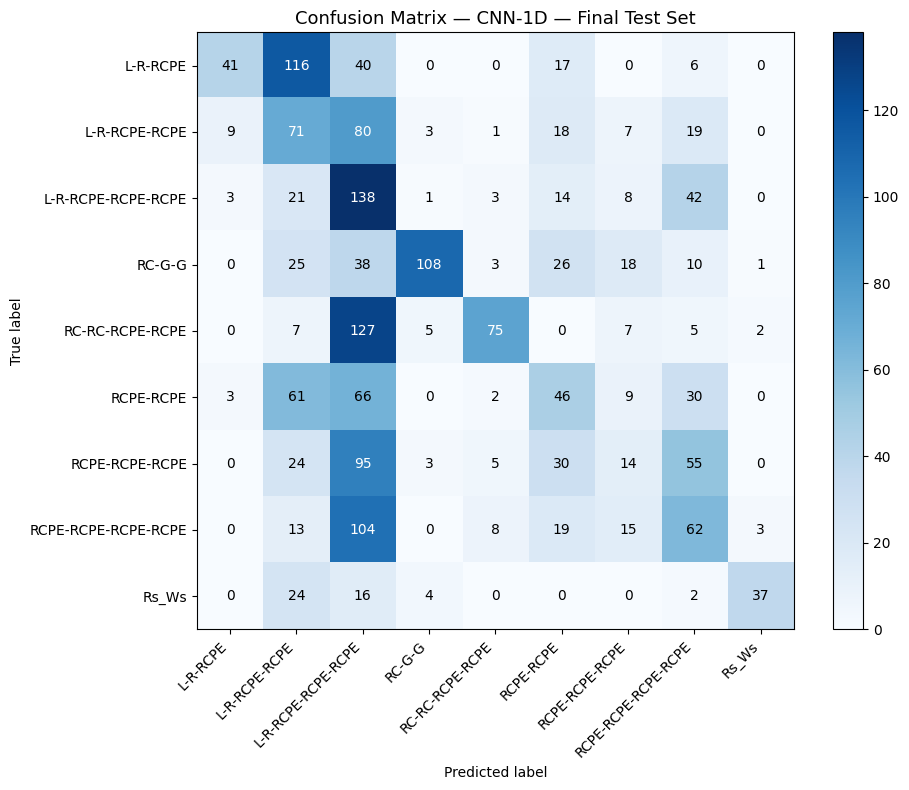

In [12]:
cm = confusion_matrix(y_test_enc, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix — CNN-1D — Final Test Set", fontsize=13)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right")
ax.set_yticklabels(label_encoder.classes_)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix_cnn1d.png", dpi=150)
plt.show()

## 12. (Optional) Export model cho STM32Cube.AI / TFLite

CNN-1D nhỏ gọn có thể deploy trực tiếp lên MCU.

In [13]:
EXPORT_TFLITE = False  # Đặt True nếu muốn export

if EXPORT_TFLITE:
    # ── SavedModel ──────────────────────────────────────────────────────────
    model.save("cnn1d_impedance.keras")
    print("Model saved to cnn1d_impedance.keras")

    # ── TFLite (float32) ───────────────────────────────────────────────────
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    with open("cnn1d_impedance.tflite", "wb") as f:
        f.write(tflite_model)
    print(f"TFLite model size: {len(tflite_model)/1024:.1f} kB")

    # ── TFLite (int8 quantized) ────────────────────────────────────────────
    def representative_dataset():
        for i in range(min(200, len(X_train))):
            yield [X_train[i:i+1].astype(np.float32)]

    converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
    converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_q.representative_dataset = representative_dataset
    converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_q.inference_input_type  = tf.int8
    converter_q.inference_output_type = tf.int8

    tflite_quant = converter_q.convert()
    with open("cnn1d_impedance_int8.tflite", "wb") as f:
        f.write(tflite_quant)
    print(f"Int8 TFLite model size: {len(tflite_quant)/1024:.1f} kB")

## 13. Tổng kết so sánh SVM vs CNN-1D

| | SVM (rbf) | CNN-1D |
|---|---|---|
| Input shape | (N, 180) — flattened | (N, 30, 6) — sequential |
| Feature locality | ✗ Không khai thác | ✓ Conv captures local patterns |
| Scale với data | Chậm (kernel matrix O(N²)) | Nhanh (mini-batch SGD) |
| Interpretability | Khó | Trung bình |
| Export MCU | Cần sklearn2c/ONNX | TFLite trực tiếp |
| Tuning | C, gamma (2 params) | LR, dropout, arch (nhiều hơn) |